# Figure 2 |  Regional mangrove area dynamics and country-level change rates. 

- Panel **a–d**: Time series of mangrove area (km²) from the late 1980s to 2023 for (**a**) Asia, (**b**) Americas, (**c**) Africa, and (**d**) Oceania. Within each continental plot, individual lines represent distinct biogeographical regions, with corresponding geographical extents shown in the inset maps in matching colors. For enhanced visualization, the Middle East is grouped with Africa. 

- Panel **e**: Mangrove change rates for the top-10 mangrove-rich nations in the 1980s, ordered by their mangrove extent. Teal bars indicate expansion rates, pink bars show deforestation rates, and grey bars represent the net change rate.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
from tqdm import tqdm
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [ ]:
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import cartopy.feature as cfeature

def GMWarea_range(area,ua,pa):
    """
    Calculate extent area range by GMW method
    ua: 95th percentile of UA
    pa: 95th percentile of PA
    area: Map area
    """
    lower = area-(area*(1-ua))
    upper = area+(area*(1-pa))
    return lower, upper

plt.rcParams['axes.facecolor'] = 'White'
os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
df_total = pd.read_csv('Code_Data/ByContinent_Total.csv'); df_total.rename(columns={df_total.columns[0]: "region"}, inplace=True);
df_total['region'] = ['Australia & New Zealand','East Asia','Eastern and Southern Africa','North and Central America','Pacific Islands',
                  'South America','South Asia','Southeast Asia','The Middle East','West and Central Africa','Global']
df_total.insert(0,'Continent',['Oceania','Asia','Africa','Americas','Oceania','Americas','Asia','Asia','Africa','Africa','Global'])
df = df_total[df_total['Continent'] != 'Global']

df_change = pd.read_csv('Code_Data/Baseline_country.csv')
top_10 = df_change.nlargest(10, '1980s')
top_10['Loss8410'] = -top_10['Loss8410']
top_10['Net8410'] = top_10['Gain8410'] + top_10['Loss8410']
top_10['GainRate8410'] = 100*top_10['Gain8410'] / top_10['1980s'];top_10['LossRate8410'] = 100*top_10['Loss8410'] / top_10['1980s'];top_10['NetRate8410'] = 100*top_10['Net8410'] / top_10['1980s']
top_10['Loss1023'] = -top_10['Loss1023']
top_10['Net1023'] = top_10['Gain1023'] + top_10['Loss1023']
top_10['GainRate1023'] = 100*top_10['Gain1023'] / top_10['2010'];top_10['LossRate1023'] = 100*top_10['Loss1023'] / top_10['2010'];top_10['NetRate1023'] = 100*top_10['Net1023'] / top_10['2010']
top_10.insert(1, 'Continent', ['Asia','Americas','Oceania','Africa','America','Asia','Asia','Oceania','Asia','America'])
top_10.rename(columns={'Unnamed: 0': 'Countries'}, inplace=True)


years = [str(year) for year in range(1984, 2024)]
df_melted = df.melt(id_vars=['Continent', 'region'], value_vars=years, var_name='Year', value_name='Value')
df_melted['Value'] = df_melted['Value'] / 1000
continents = df['Continent'].unique()


<Figure size 640x480 with 0 Axes>

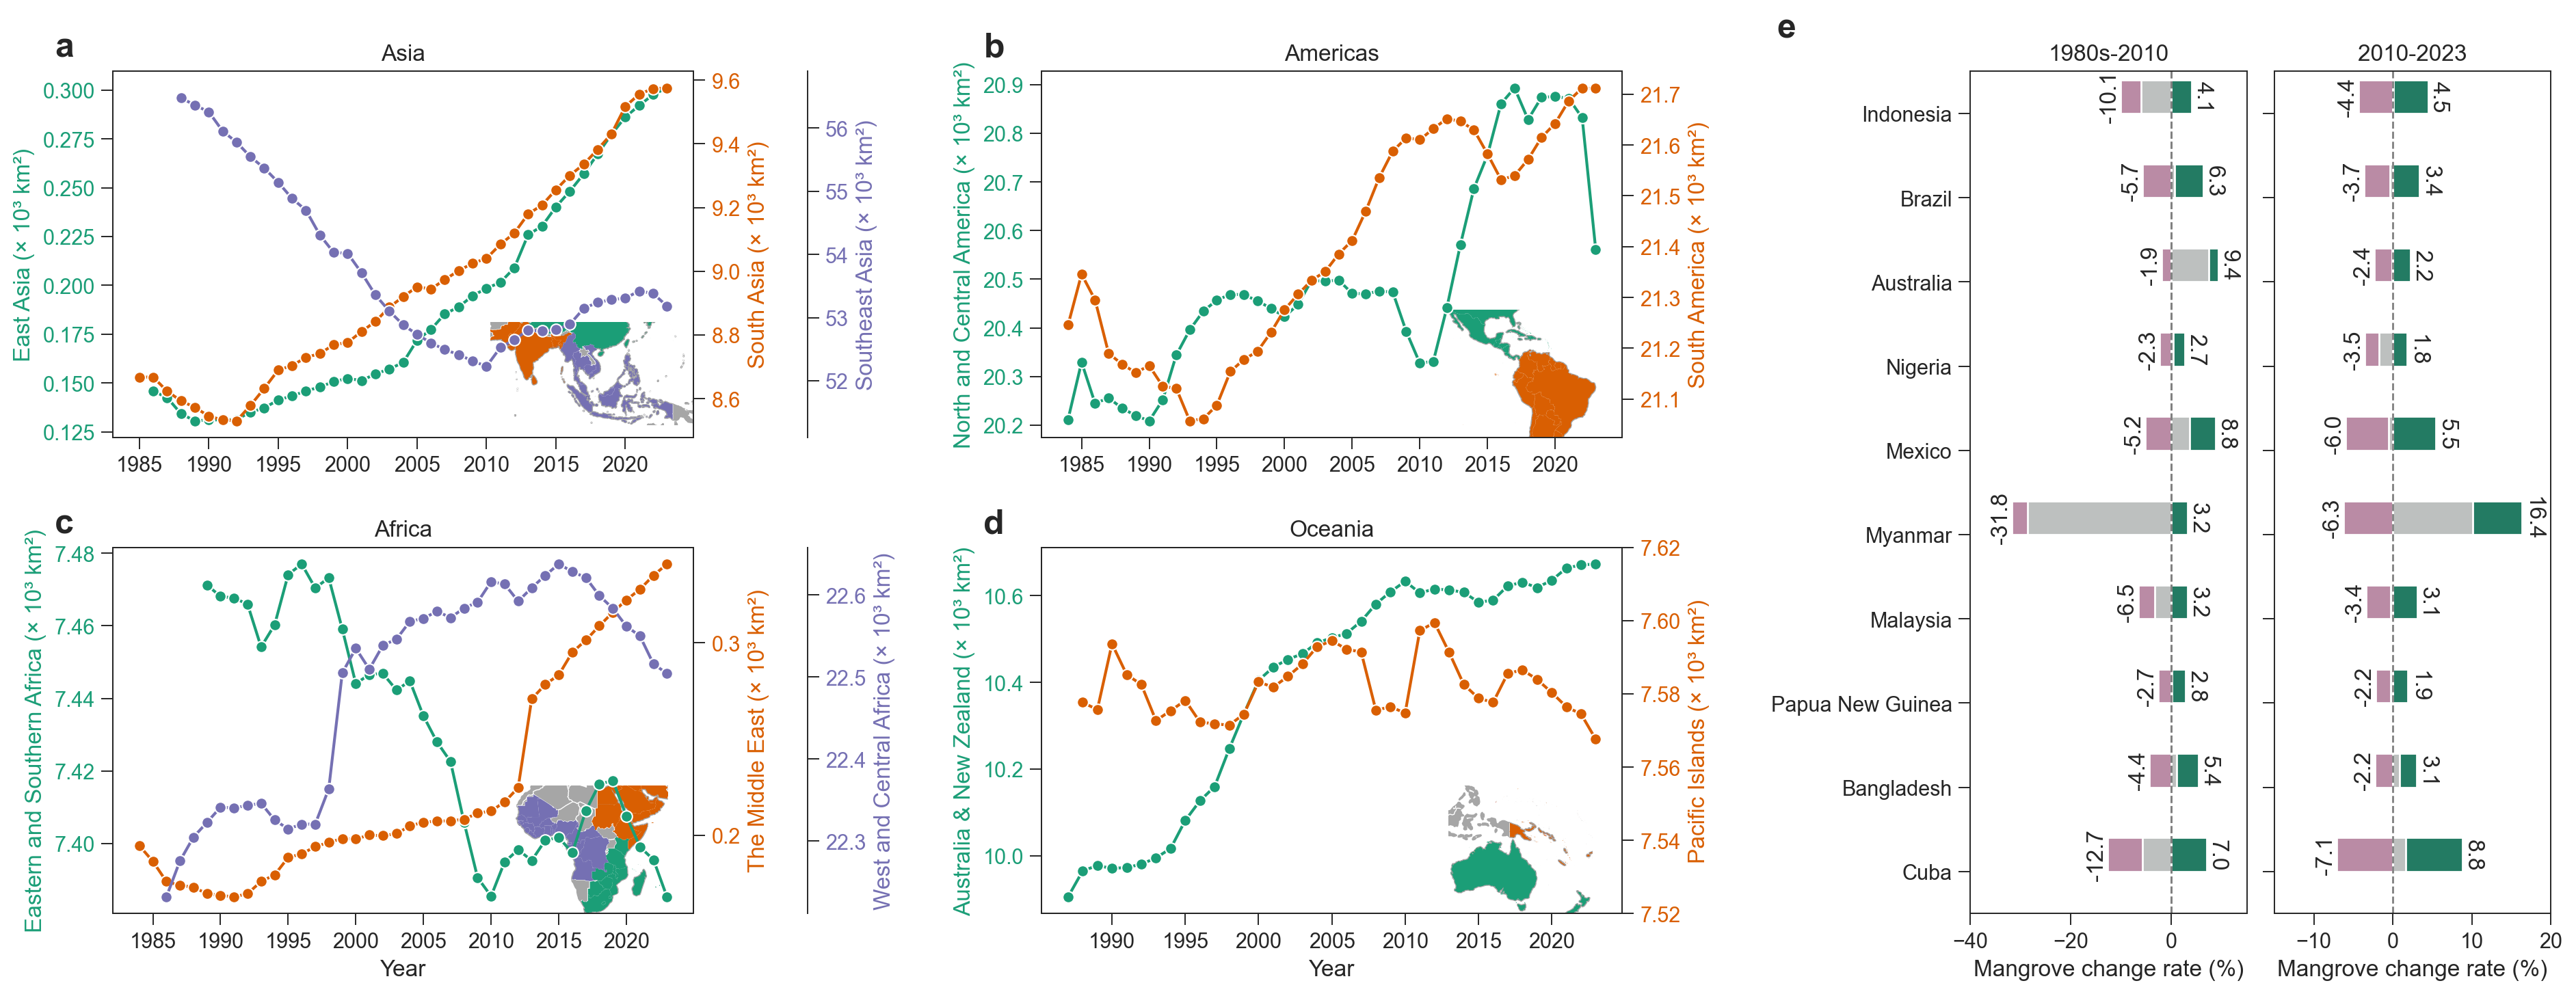

In [ ]:
sns.set_context("notebook")
sns.set(style='ticks', palette='Dark2')
sns.despine() #to remove "chartjunk"
fig = plt.figure(figsize=(23,8))
gs = GridSpec(nrows=2, ncols=3,width_ratios=[1,1,1],figure=fig)
gs.update(wspace=0.6)
letters = ['a','b','c','d','e']  
axes = []

# Plotting time series for each continent
for idx, continent in enumerate(['Asia','Americas','Africa','Oceania']):  
    continent_data = df_melted[df_melted['Continent'] == continent]
    continent_data['Year'] = continent_data['Year'].astype(int)  
    regions = continent_data['region'].unique()  
    num_hues = len(regions)  

    if idx < 2:
        ax_main = fig.add_subplot(gs[0,idx])
    else:
        ax_main = fig.add_subplot(gs[1,idx-2])
    axes.append(ax_main)  
    ax_main.set_title(continent)
    ax_main.set_ylabel(f"{regions[0]} (× 10³ km²)", color='C0') 
    sns.lineplot(data=continent_data[continent_data['region'] == regions[0]], 
                 x='Year', y='Value', marker='o', color='C0', ax=ax_main,zorder=10)
    if idx < 2:
        ax_main.set_xlabel('')
    else:
        ax_main.set_xlabel('Year')
    ax_main.tick_params(axis='y', labelcolor='C0')
    plt.text(-0.1,1.04,letters[idx],fontdict={'weight' : 'bold', 'size' : 18}, transform=ax_main.transAxes)
    ZhenPlot.spine_setting(ax_main,linewidth=0.7)

    # Additional Y-axes for other regions
    for i in range(1, num_hues):
        ax_twin = ax_main.twinx()
        ax_twin.spines['right'].set_position(('outward', 60 * (i - 1)))  # Offset each additional y-axis
        sns.lineplot(data=continent_data[continent_data['region'] == regions[i]], 
                     x='Year', y='Value', marker='o', color=f'C{i}', ax=ax_twin)
        # add_errorbars(ax_twin, continent_data[continent_data['region'] == regions[i]], color=f'C{i}', step=1)
        ax_twin.set_ylabel(f"{regions[i]} (× 10³ km²)", color=f'C{i}')
        # ax_twin.set_ylabel("", color=f'C{i}')
        ax_twin.tick_params(axis='y', labelcolor=f'C{i}')
        if regions[i] == 'The Middle East':
            ax_twin.yaxis.set_major_locator(ticker.MultipleLocator(0.1))  # Tick interval of 0.1
            ax_twin.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        elif regions[i] == 'West and Central Africa':
            ax_twin.yaxis.set_major_locator(ticker.MultipleLocator(0.1))  # Tick interval of 0.1
            ax_twin.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        if regions[i] == 'Southeast Asia':
            ax_twin.set_ylim(51.1,56.9)  # Set y-axis limits for Southeast Asia
        if regions[i] == 'Pacific Islands':
            ax_twin.set_ylim(7.52,7.62)  # Set y-axis limits for Pacific Islands due to small change
        ZhenPlot.spine_setting(ax_twin,linewidth=0.7)
        
#------Plotting bar charts for top-10 countries------
sub_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[:, 2], wspace=0.1)  
ax_bar1 = fig.add_subplot(sub_gs[0, 0])  
ax_bar2  = fig.add_subplot(sub_gs[0, 1]) 

sns.barplot(data=top_10,y=top_10.columns[0],x='GainRate8410',color='#148a6a',ax=ax_bar1,orient='h')
sns.barplot(data=top_10,y=top_10.columns[0],x='LossRate8410',color='#c283a6',ax=ax_bar1,orient='h')
sns.barplot(data=top_10,y=top_10.columns[0],x='NetRate8410',color='#bdc0bf',ax=ax_bar1,orient='h')
for patch in ax_bar1.patches:
    patch.set_height(0.4) # Set bar height, default is about 0.8
ax_bar1.axvline(0, color='grey', linewidth=1,ls='--')
ax_bar1.set_xlabel('Mangrove change rate (%)');ax_bar1.set_ylabel('')
ax_bar1.set_title('1980s-2010')
ax_bar1.bar_label(ax_bar1.containers[0], fmt='%.1f',rotation=270)
ax_bar1.bar_label(ax_bar1.containers[1], fmt='%.1f',rotation=90)
ax_bar1.set_xlim(-40,15)
ZhenPlot.spine_setting(ax_bar1,linewidth=0.7)
plt.text(-0.7,1.04,'e',fontdict={'weight' : 'bold', 'size' : 18}, transform=ax_bar1.transAxes)

sns.barplot(data=top_10,y=top_10.columns[0],x='GainRate1023',color='#148a6a',ax=ax_bar2,alpha=1,orient='h')
sns.barplot(data=top_10,y=top_10.columns[0],x='LossRate1023',color='#c283a6',ax=ax_bar2,alpha=1,orient='h')
sns.barplot(data=top_10,y=top_10.columns[0],x='NetRate1023',color='#bdc0bf',ax=ax_bar2,alpha=1,orient='h')
for patch in ax_bar2.patches:
    patch.set_height(0.4)  
ax_bar1.axvline(0, color='grey', linewidth=1,ls='--')
ax_bar2.axvline(0, color='grey', linewidth=1,ls='--')
ax_bar2.set_xlabel('Mangrove change rate (%)');ax_bar2.set_ylabel('')
ax_bar2.set_title('2010-2023')
ax_bar2.set_yticklabels([]);
ax_bar2.bar_label(ax_bar2.containers[0], fmt='%.1f',rotation=270)
ax_bar2.bar_label(ax_bar2.containers[1], fmt='%.1f',rotation=90)
ax_bar2.set_xlim(-15,20)
ZhenPlot.spine_setting(ax_bar2,linewidth=0.7)

#---------------------Adding inset map---------------------
ax=axes[0]
for ax in axes:
    inset_ax = ax.inset_axes([0.65, 0, 0.35, 0.35],  # [x, y, width, height]，coordinates are relative to the parent axes
                            projection=ccrs.PlateCarree()) 
    if ax == axes[0]:
        lon_min, lon_max,lat_min,lat_max = 61.58, 150,-11.55, 33 # Asia
        inset_ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        gpd.read_file(r'Code_Data\CountryBorder\EastAsia.shp').plot(ax=inset_ax, facecolor='C0', edgecolor='none')
        gpd.read_file(r'Code_Data\CountryBorder\SouthAsia.shp').plot(ax=inset_ax, facecolor='C1', edgecolor='none')
        gpd.read_file(r'Code_Data\CountryBorder\SoutheastAsia.shp').plot(ax=inset_ax, facecolor='C2', edgecolor='none')
    elif ax == axes[1]:
        lon_min, lon_max,lat_min,lat_max = -120, -34, -34, 34 # Americas
        inset_ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        gpd.read_file(r'Code_Data\CountryBorder\NorthAmerica.shp').plot(ax=inset_ax, facecolor='C0', edgecolor='none')
        gpd.read_file(r'Code_Data\CountryBorder\SouthAmerica.shp').plot(ax=inset_ax, facecolor='C1', edgecolor='none')
    elif ax == axes[2]:
        lon_min, lon_max,lat_min,lat_max = -18, 62, -35, 32 # Africa
        inset_ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        gpd.read_file(r'Code_Data\CountryBorder\EastAfrica.shp').plot(ax=inset_ax, facecolor='C0', edgecolor='none',zorder=-10)
        gpd.read_file(r'Code_Data\CountryBorder\MiddleEast.shp').plot(ax=inset_ax, facecolor='C1', edgecolor='none',zorder=-10)
        gpd.read_file(r'Code_Data\CountryBorder\WestAfrica.shp').plot(ax=inset_ax, facecolor='C2', edgecolor='none',zorder=-10)
    elif ax == axes[3]:
        lon_min, lon_max,lat_min,lat_max = 112, 180, -45, 15 # Oceania
        inset_ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        gpd.read_file(r'Code_Data\CountryBorder\AustraliaAndNZ.shp').plot(ax=inset_ax, facecolor='C0', edgecolor='none')
        gpd.read_file(r'Code_Data\CountryBorder\PacificIslands.shp').plot(ax=inset_ax, facecolor='C1', edgecolor='none')
    inset_ax.add_feature(cfeature.LAND,color='#a6a6a6',zorder=-11)
    inset_ax.add_feature(cfeature.BORDERS,color='white',lw=0.5,zorder=-11)
    inset_ax.set_frame_on(False)


inset_ax.scatter(120, 30, s=50, color='red', transform=ccrs.PlateCarree())
plt.subplots_adjust(hspace = 0.3)

plt.savefig("Figures/Fig2.png", dpi=500, format='png', bbox_inches='tight')
plt.savefig("Figures/Fig2.pdf", dpi=500, format='pdf', bbox_inches='tight')